In [1]:
import warnings
warnings.filterwarnings("ignore")


In [2]:
from typing import TypedDict, Optional
from langgraph.graph import StateGraph
from langgraph.checkpoint.memory import InMemorySaver
 
# --- State Schema ---
class AgentState(TypedDict, total=False):
    name: Optional[str]
    greeting: Optional[str]
    message: Optional[str]
 
# --- Nodes ---
def greet_node(state: AgentState) -> AgentState:
    state["greeting"] = "Hello"
    return state
 
def personalize_node(state: AgentState) -> AgentState:
    state["message"] = f"{state['greeting']}, {state.get('name', 'Guest')}!"
    return state
 
# --- Build Graph ---
builder = StateGraph(AgentState)
builder.add_node("Greet", greet_node)
builder.add_node("Personalize", personalize_node)
builder.set_entry_point("Greet")
builder.add_edge("Greet", "Personalize")
 
# --- Compile Graph ---
graph = builder.compile(checkpointer=InMemorySaver())
 
# --- Config ---
config = {"configurable": {"thread_id": "session_1"}}
 
# --- Run Graph ---
initial_state = {"name": "ABC"}
final_state = graph.invoke(initial_state, config=config)
print("Final State:", final_state)
############################################################
# --- Get History ---
history = list(graph.get_state_history(config=config))
print("\nCheckpoints:")
for i, entry in enumerate(history):
    if isinstance(entry, tuple):
        checkpoint_id = entry[0]
        data = entry[1]
        values = data.get("values") if isinstance(data, dict) else data
        print(f"{i}: ID={checkpoint_id}, State={values}")
    elif isinstance(entry, dict):
        print(f"{i}: ID={entry.get('checkpoint_id')}, State={entry.get('values')}")
 
# --- Update State ---
 
graph.update_state( config, values={"name": "User_1"})
 
# Time travel (just re-invoke from start)
time_travel_config = {"configurable": {"thread_id": "session_1"}}
new_state = graph.invoke(None, config=time_travel_config)
print("Time Travelled State:", new_state)


Final State: {'name': 'ABC', 'greeting': 'Hello', 'message': 'Hello, ABC!'}

Checkpoints:
0: ID={'name': 'ABC', 'greeting': 'Hello', 'message': 'Hello, ABC!'}, State=()
1: ID={'name': 'ABC', 'greeting': 'Hello'}, State=('Personalize',)
2: ID={'name': 'ABC'}, State=('Greet',)
3: ID={}, State=('__start__',)
Time Travelled State: {'name': 'User_1', 'greeting': 'Hello', 'message': 'Hello, ABC!'}


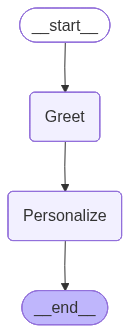

In [3]:
graph